## 1. Business Understanding

###1.1 Problem Definition

#####The telecommunications industry serves customers with diverse behaviors, service preferences, and usage patterns. Understanding these differences is essential for improving customer satisfaction, reducing churn, and increasing business value through data-driven decisions.

#####This project develops a Customer Intelligence Platform using the Telco Customer Churn dataset. It combines customer segmentation through K-Means clustering and churn prediction using supervised machine learning to identify customer groups and predict customers at risk of leaving. The project also includes a business and revenue impact analysis, demonstrating how these insights can support personalized retention strategies, targeted marketing campaigns, and data-driven decision-making to improve customer experience and profitability.

###1.2 Objective

Logistic Regression:
* Predict whether a customer is likely to churn.


Customer Segmentation:
* Discover meaningful customer segments based on customer characteristics
* Compare the performance of different clustering algorithms.            
* Visualize and interpret the identified customer groups.

#Importing Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import math
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")

##2. Data Understanding

###2.1 Data Source
#####The dataset used in this project is the Telco Customer Churn dataset, publicly available on Kaggle. It contains demographic information, subscribed services, account details, and billing information for 7,043 customers from a telecommunications company. Although the dataset originally includes a Churn variable, this project focuses on customer segmentation using unsupervised learning.

##### Kaggle: https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data


### Dataset Loading

Dataset First View

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Checking Data Type

In [3]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Dataset Rows & Columns count

In [4]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 7043
Number of Columns: 21


Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Statistical Summary

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#####**Customer Demographics**: gender, SeniorCitizen, Partner, Dependents
#####**Subscription Information**: PhoneService, MultipleLines, InternetService
#####**Value-Added Services**: OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies
#####**Contract & Billing Information**: Contract, PaperlessBilling, PaymentMethod
#####**Customer Account & Charges**: tenure, MonthlyCharges, TotalCharges
#####**Customer Identifier**: customerID (removed before modeling because it is only a unique identifier and does not contribute to clustering.)
#####**Target Variable (Excluded)**: Churn (excluded from the clustering process because this project uses unsupervised learning to discover natural customer segments rather than predict customer churn.)


# Creating Copies

In [7]:
df_churn = df.copy()
df_segmentation = df.copy()
df_analysis = df.copy()

Why separate copies were created?

Although all three dataframes originate from the same dataset, each machine learning task requires a different preprocessing strategy

*   df_churn is prepared for supervised learning.
*   df_segmentation is prepared for unsupervised learning.
*   df_analysis to perform revenue impact analysis



# 3. Supervised Learning

##3.1 Data Cleaning & Preprocessing

In [8]:
df_churn.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [9]:
df_churn.duplicated().sum()

np.int64(0)

In [10]:
df_churn['TotalCharges'] = pd.to_numeric(df_churn['TotalCharges'], errors='coerce')
df_churn['TotalCharges'] = df_churn['TotalCharges'].fillna(0)

In [11]:
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection','StreamingTV', 'StreamingMovies']

df_churn['HasService'] = (df_churn[services] == 'Yes').any(axis=1).astype(int)
df_churn = df_churn.drop(services, axis=1)
df_churn = df_churn.drop(columns=['customerID','PaperlessBilling','PaymentMethod'], axis=1)
df_churn['Churn'] = df_churn['Churn'].map({'Yes': 1, 'No': 0})
df_churn['TechSupport'] = df_churn['TechSupport'].map({'Yes': 1, 'No': 0, 'No internet service': 0})
df_churn['MultipleLines'] = df_churn['MultipleLines'].map({'Yes': 1, 'No': 0, 'No phone service': 0})
df_churn['PhoneService'] = df_churn['PhoneService'].map({'Yes': 1, 'No': 0})
df_churn['Partner'] = df_churn['Partner'].map({'Yes': 1, 'No': 0})
df_churn['Dependents'] = df_churn['Dependents'].map({'Yes': 1, 'No': 0})
df_churn['MonthlyCharges'] = df_churn['MonthlyCharges'] * 3.75
df_churn['TotalCharges'] = df_churn['TotalCharges'] * 3.75

In [12]:
df_churn.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,TechSupport,Contract,MonthlyCharges,TotalCharges,Churn,HasService
0,Female,0,1,0,1,0,0,DSL,0,Month-to-month,111.9375,111.9375,0,1
1,Male,0,0,0,34,1,0,DSL,0,One year,213.5625,7085.6250,0,1
2,Male,0,0,0,2,1,0,DSL,0,Month-to-month,201.9375,405.5625,1,1
3,Male,0,0,0,45,0,0,DSL,1,One year,158.6250,6902.8125,0,1
4,Female,0,0,0,2,1,0,Fiber optic,0,Month-to-month,265.1250,568.6875,1,0


<Axes: >

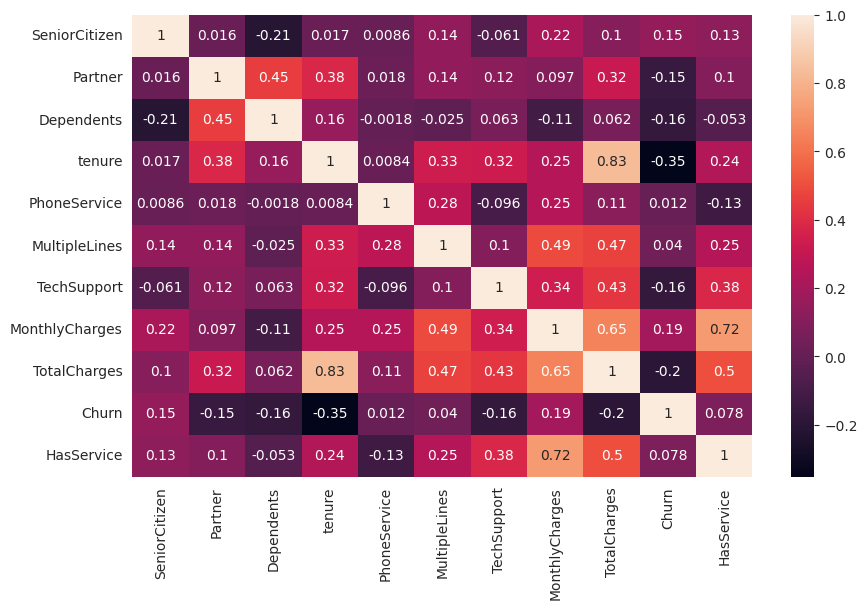

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_churn.corr(numeric_only=True), annot=True)

* We noticed that the churn is really effected by the monthly charges and if the customer is senior citizen or not




/tmp/ipykernel_4968/4237009310.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_churn, x='Contract', y='Churn', ax=axes[0, 0], palette='Blues_r', errorbar=None)
/tmp/ipykernel_4968/4237009310.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_churn, x='TechSupport', y='Churn', ax=axes[0, 1], palette='Reds_r', errorbar=None)


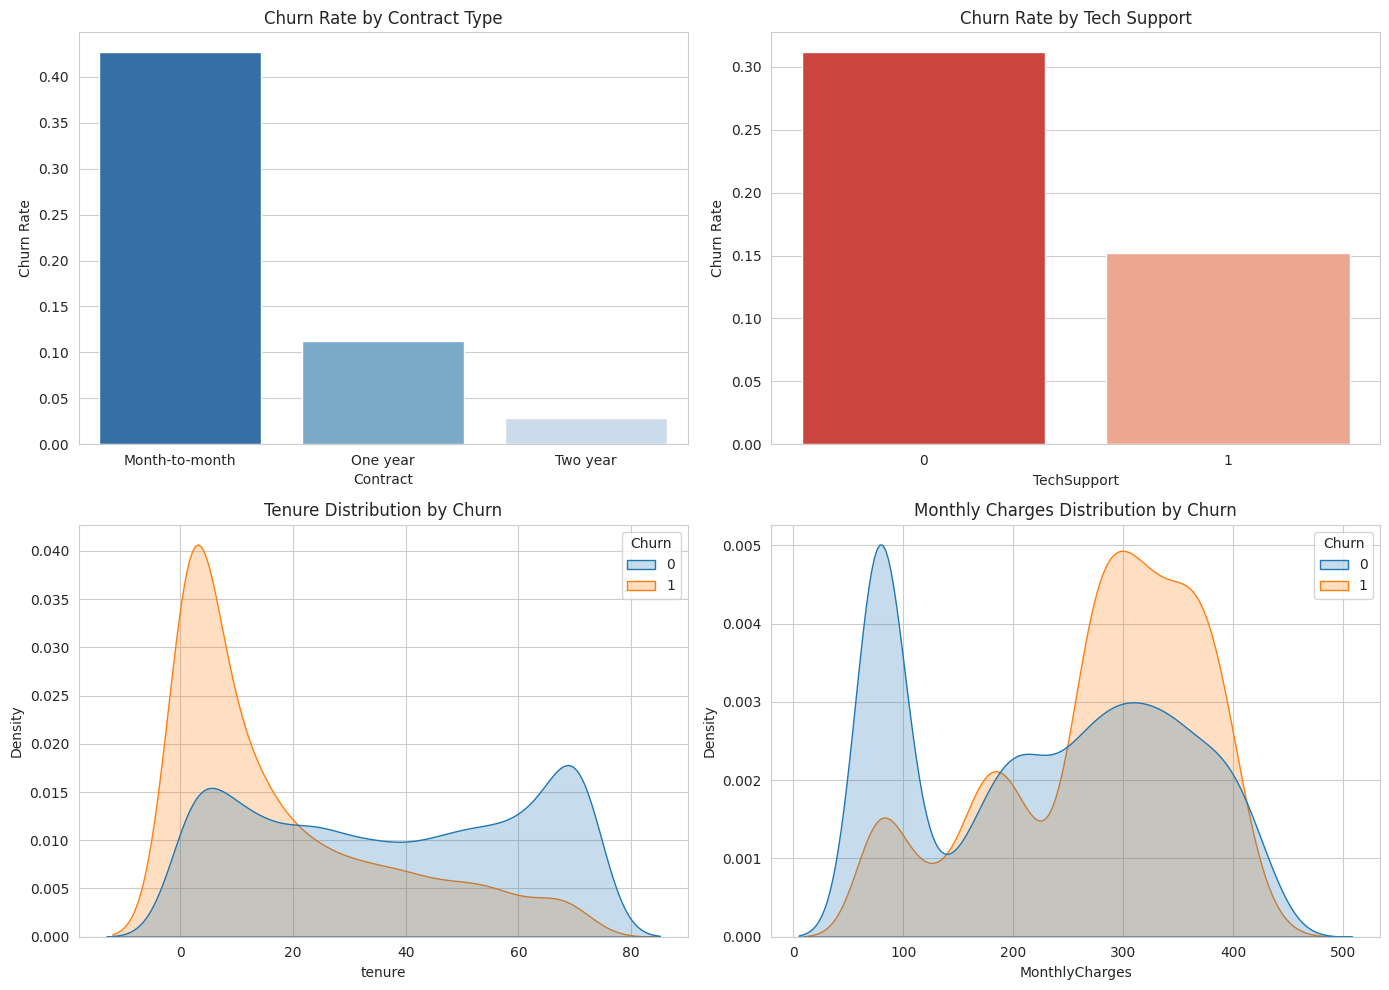

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(data=df_churn, x='Contract', y='Churn', ax=axes[0, 0], palette='Blues_r', errorbar=None)
axes[0, 0].set_title('Churn Rate by Contract Type')
axes[0, 0].set_ylabel('Churn Rate')

sns.barplot(data=df_churn, x='TechSupport', y='Churn', ax=axes[0, 1], palette='Reds_r', errorbar=None)
axes[0, 1].set_title('Churn Rate by Tech Support')
axes[0, 1].set_ylabel('Churn Rate')

sns.kdeplot(data=df_churn, x='tenure', hue='Churn', fill=True, ax=axes[1, 0], common_norm=False)
axes[1, 0].set_title('Tenure Distribution by Churn')

sns.kdeplot(data=df_churn, x='MonthlyCharges', hue='Churn', fill=True, ax=axes[1, 1], common_norm=False)
axes[1, 1].set_title('Monthly Charges Distribution by Churn')

plt.tight_layout()
plt.show()

* As we can see in the figures , most of the churned customers and month to month customers and they don't have Tech Support service also most of them are new customers with high monthly charges

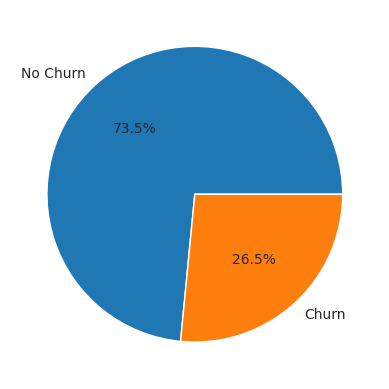

In [15]:
plt.pie(df_churn['Churn'].value_counts(), labels=['No Churn', 'Churn'], autopct='%1.1f%%');

* As we can see, we have class imbalance in our label , we will try to handel it and compier the models with balanced label and imbalanced

In [16]:
df_churn = pd.get_dummies(df_churn, columns=['gender', 'InternetService', 'Contract'], drop_first=True)

## 3.2 Model Training & Evaluation

In [17]:
X = df_churn.drop('Churn', axis=1)
y = df_churn['Churn']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler_churn = StandardScaler()
X_train[num_cols] = scaler_churn.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler_churn.transform(X_test[num_cols])

In [19]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

lr_y_pred = lr.predict(X_test)

rm = RandomForestClassifier()
rm.fit(X_train, y_train)

rm_y_pred = rm.predict(X_test)

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

gb_y_pred = gb.predict(X_test)

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

xgb_y_pred = xgb.predict(X_test)

In [20]:
print('Before Handling imbalance: ')
print("Logistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, lr_y_pred))
print("Precision:", precision_score(y_test, lr_y_pred))
print("Recall:", recall_score(y_test, lr_y_pred))
print("F1 Score:", f1_score(y_test, lr_y_pred))

print("\nRandom Forest Metrics:")
print("Accuracy:", accuracy_score(y_test, rm_y_pred))
print("Precision:", precision_score(y_test, rm_y_pred))
print("Recall:", recall_score(y_test, rm_y_pred))
print("F1 Score:", f1_score(y_test, rm_y_pred))

print("\nGradient Boosting Metrics:")
print("Accuracy:", accuracy_score(y_test, gb_y_pred))
print("Precision:", precision_score(y_test, gb_y_pred))
print("Recall:", recall_score(y_test, gb_y_pred))
print("F1 Score:", f1_score(y_test, gb_y_pred))

print("\nXGBoost Metrics:")
print("Accuracy:", accuracy_score(y_test, xgb_y_pred))
print("Precision:", precision_score(y_test, xgb_y_pred))
print("Recall:", recall_score(y_test, xgb_y_pred))
print("F1 Score:", f1_score(y_test, xgb_y_pred))

Before Handling imbalance: 
Logistic Regression Metrics:
Accuracy: 0.8048261178140526
Precision: 0.653125
Recall: 0.5603217158176944
F1 Score: 0.6031746031746031

Random Forest Metrics:
Accuracy: 0.7799858055358411
Precision: 0.6105263157894737
Recall: 0.46648793565683644
F1 Score: 0.5288753799392097

Gradient Boosting Metrics:
Accuracy: 0.8055358410220014
Precision: 0.6774193548387096
Recall: 0.5067024128686327
F1 Score: 0.5797546012269938

XGBoost Metrics:
Accuracy: 0.8019872249822569
Precision: 0.6516129032258065
Recall: 0.5415549597855228
F1 Score: 0.5915080527086384


In [21]:
lr = LogisticRegression(max_iter=1000,class_weight='balanced' , random_state=42)
lr.fit(X_train, y_train)

lr_y_pred = lr.predict(X_test)

rm = RandomForestClassifier(n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42, class_weight='balanced')
rm.fit(X_train, y_train)

rm_y_pred = rm.predict(X_test)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
gb = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42)
gb.fit(X_train, y_train , sample_weight=sample_weights)
gb_y_pred = gb.predict(X_test)

scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_y_pred = xgb.predict(X_test)

In [22]:
print('After Handling imbalance: ')
print("Logistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, lr_y_pred))
print("Precision:", precision_score(y_test, lr_y_pred))
print("Recall:", recall_score(y_test, lr_y_pred))
print("F1 Score:", f1_score(y_test, lr_y_pred))

print("\nRandom Forest Metrics:")
print("Accuracy:", accuracy_score(y_test, rm_y_pred))
print("Precision:", precision_score(y_test, rm_y_pred))
print("Recall:", recall_score(y_test, rm_y_pred))
print("F1 Score:", f1_score(y_test, rm_y_pred))

print("\nGradient Boosting Metrics:")
print("Accuracy:", accuracy_score(y_test, gb_y_pred))
print("Precision:", precision_score(y_test, gb_y_pred))
print("Recall:", recall_score(y_test, gb_y_pred))
print("F1 Score:", f1_score(y_test, gb_y_pred))

print("\nXGBoost Metrics:")
print("Accuracy:", accuracy_score(y_test, xgb_y_pred))
print("Precision:", precision_score(y_test, xgb_y_pred))
print("Recall:", recall_score(y_test, xgb_y_pred))
print("F1 Score:", f1_score(y_test, xgb_y_pred))

After Handling imbalance: 
Logistic Regression Metrics:
Accuracy: 0.7437899219304471
Precision: 0.5098684210526315
Recall: 0.8310991957104558
F1 Score: 0.6320081549439348

Random Forest Metrics:
Accuracy: 0.7821149751596878
Precision: 0.5632183908045977
Recall: 0.7882037533512064
F1 Score: 0.6569832402234637

Gradient Boosting Metrics:
Accuracy: 0.7665010645848119
Precision: 0.5398550724637681
Recall: 0.7989276139410187
F1 Score: 0.6443243243243243

XGBoost Metrics:
Accuracy: 0.7629524485450674
Precision: 0.5357798165137615
Recall: 0.7828418230563002
F1 Score: 0.6361655773420479


| Model | Stage | Accuracy | Precision | Recall | F1 Score |
|---|---|---|---|---|---|
| Logistic Regression | Before balancing | 0.8048 | 0.6531 | 0.5603 | 0.6032 |
| Logistic Regression | **After balancing** | **0.7438** | **0.5099** | **0.8311** | **0.6320** |
| Random Forest | Before balancing | 0.7771 | 0.6042 | 0.4584 | 0.5213 |
| Random Forest | **After balancing** | **0.7821** | **0.5632** | **0.7882** | **0.6570** |
| Gradient Boosting | Before balancing | 0.8055 | 0.6774 | 0.5067 | 0.5798 |
| Gradient Boosting | **After balancing** | **0.7665** | **0.5399** | **0.7989** | **0.6443** |
| XGBoost | Before balancing | 0.8020 | 0.6516 | 0.5416 | 0.5915 |
| XGBoost | **After balancing** | **0.7630** | **0.5358** | **0.7828** | **0.6362** |

* Logistic Regression achieved the highest Recall (83.11%) after handling the imbalance, making it the best model for catching potential churners with is the main goal of this project.

* Random Forest achieved the highest F1 Score (0.6570) with a strong Recall (78.82%) and the highest Accuracy (78.21%) it'll be a good choice if we want a balanced model.

In [24]:
import joblib

joblib.dump(lr, "LogisticRegression_model.pkl")
joblib.dump(scaler_churn, "scaler.pkl")

print("Model Saved")

Model Saved


#4. Unsupervised Learning

### 4.1 Data Cleaning and Preparation

####4.1.1 Data Type Conversion

The TotalCharges column was stored as a text (object) data type instead of a numeric format. the column was converted to a numeric data type using pd.to_numeric().


In [25]:
df_segmentation["TotalCharges"] = pd.to_numeric(df_segmentation["TotalCharges"],errors="coerce")

#### 4.1.2 Handling Missing Values & Duplicate Records

In [26]:
df_segmentation.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [27]:
df_segmentation[df_segmentation["TotalCharges"].isna()][[ "tenure", "MonthlyCharges", "TotalCharges"]]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [28]:
df_segmentation["TotalCharges"] = df_segmentation["TotalCharges"].fillna(0)

#####Missing values were found only in the **TotalCharges** column for customers with a tenure of 0 months. Since these customers had not yet accumulated any charges, the missing values were replaced with 0 instead of removing the records. This approach preserved all customer observations while maintaining data consistency.

In [29]:
df_segmentation["TotalCharges"] = df_segmentation["TotalCharges"] * 3.75

In [30]:
df_segmentation["MonthlyCharges"] = df_segmentation["MonthlyCharges"] * 3.75

#### 4.1.3 Removing Irrelevant Features



- The customerID column was removed because it is only an identifier and does not contribute to clustering. The Churn column was also excluded from the clustering process because it represents a target label. The objective of this project is to discover


In [31]:
df_segmentation = df_segmentation.drop(columns =["customerID", "Churn", 'PaperlessBilling','PaymentMethod' ])

#### 4.1.4 Encoding Categorical Variables

In [32]:
binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService'
]

for col in binary_cols:
    df_segmentation[col] = df_segmentation[col].map({
        'Yes':1,
        'No':0,
        'Male':1,
        'Female':0
    })

In [33]:
df_segmentation = pd.get_dummies(df_segmentation,columns=[
        'MultipleLines',
        'InternetService',
        'OnlineSecurity',
        'OnlineBackup',
        'DeviceProtection',
        'TechSupport',
        'StreamingTV',
        'StreamingMovies',
        'Contract'
    ])

### 4.2 Feature Scaling

Feature scaling was applied using StandardScaler to standardize the numerical values. This step ensures that all features have a similar scale, preventing variables with larger numerical ranges (such as TotalCharges and MonthlyCharges) from dominating the distance calculations.

In [34]:
scaler_Segmentation = StandardScaler()
X_scaled = scaler_Segmentation.fit_transform(df_segmentation)

### 4.3 Exploratory Data Analysis (EDA)

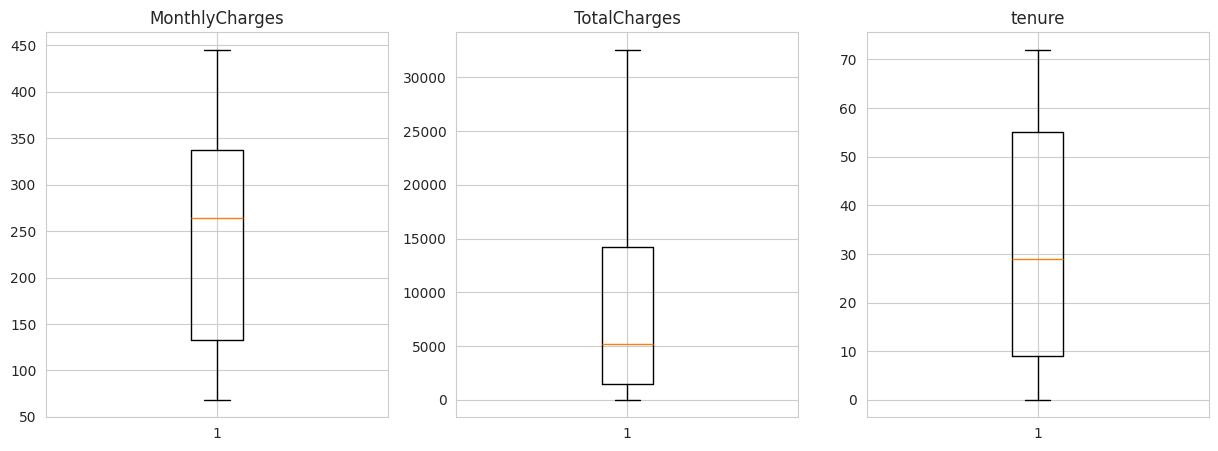

In [35]:
columns = [
    "MonthlyCharges",
    "TotalCharges",
    "tenure"
]

n_cols = 3
n_rows = math.ceil(len(columns) / n_cols)

plt.figure(figsize=(5 * n_cols, 5 * n_rows))

for i, col in enumerate(columns, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(df_segmentation[col].dropna())
    plt.title(col)

plt.show()



##### The numerical features show a reasonable distribution with no significant outliers. **MonthlyCharges** has moderate variability, while **TotalCharges** and **tenure** have wider spreads due to differences in customer spending and subscription length. No outlier treatment was applied since the values represent valid customer behavior.

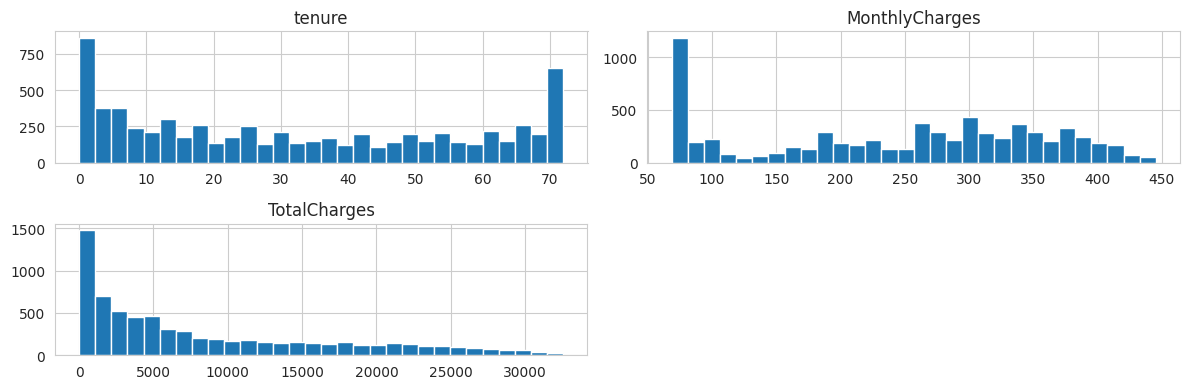

In [36]:
df_segmentation[["tenure", "MonthlyCharges", "TotalCharges"]].hist(
    figsize=(12,4),
    bins=30)

plt.tight_layout()
plt.show()

##### **Tenure** shows a mix of new and long-term customers. **MonthlyCharges** is widely distributed across different pricing plans. **TotalCharges** is right-skewed, indicating that most customers have relatively low accumulated charges, while a smaller group has much higher total spending due to longer subscriptions.

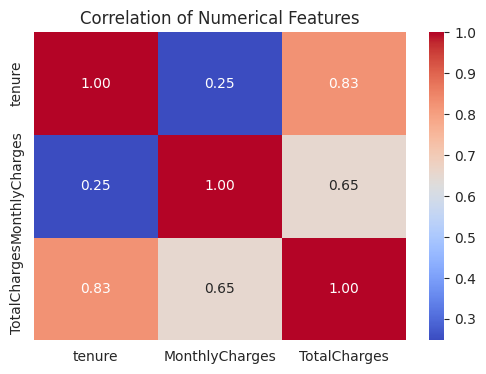

In [37]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

corr = df_segmentation[numeric_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation of Numerical Features")
plt.show()


##### **TotalCharges** is strongly correlated with **tenure** (0.83) and moderately correlated with **MonthlyCharges** (0.65), indicating that total spending increases with both subscription length and monthly fees. The weak correlation between **tenure** and **MonthlyCharges** (0.25) suggests that customer tenure has little influence on monthly charges.

### 4.4 Modeling

####4.4.1 K-Means

In [38]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)

(7043, 2)


In [39]:
kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(X_pca)

Silhouette Score

In [40]:
print("K-Means Silhouette:", silhouette_score(X_pca, clusters))

K-Means Silhouette: 0.6389758408454318


Elbow Method

In [41]:
inertia = []

for k in range(1,10):
    model = KMeans(n_clusters=k)
    model.fit(X_pca)
    inertia.append(model.inertia_)

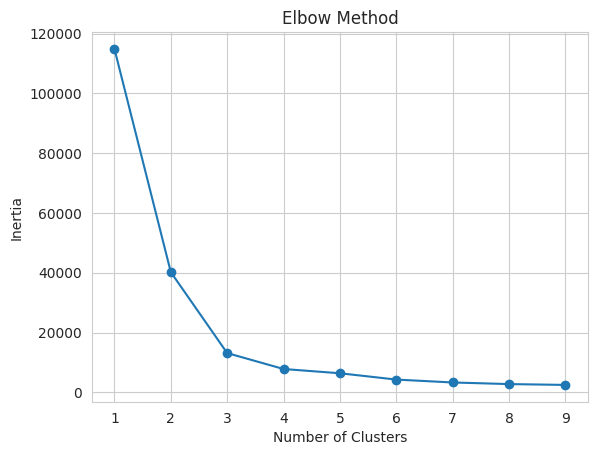

In [42]:
plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

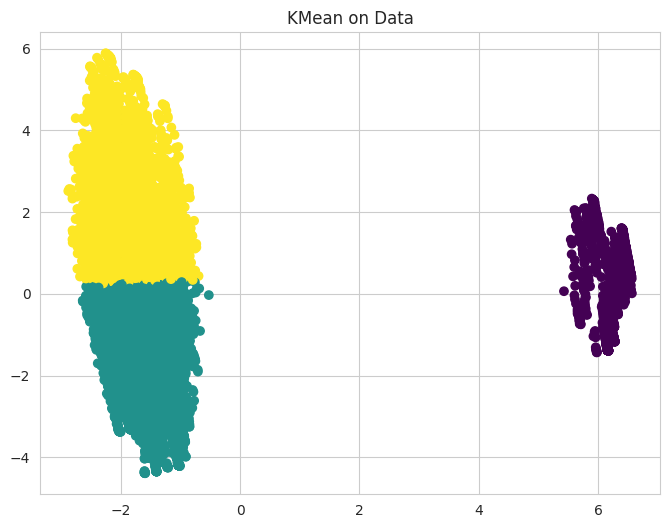

In [43]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis")
plt.title("KMean on Data")
plt.show()

#### 4.4.2 DBscan

In [44]:
db = DBSCAN( eps=0.2,min_samples=3)
clusters_db = db.fit_predict(X_pca)

Silhouette Score

In [45]:
score = silhouette_score( X_pca, clusters_db )
print("DBSCAN Silhouette Score:", score)

DBSCAN Silhouette Score: 0.45992193082048366


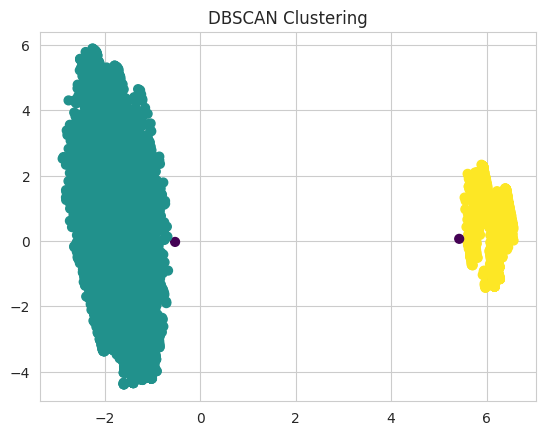

In [46]:
plt.scatter(X_pca[:,0],X_pca[:,1],c=clusters_db,cmap="viridis",s=40)
plt.title("DBSCAN Clustering")
plt.show()

###4.5 Model Comparison

The clustering algorithms were trained using the PCA-transformed dataset because it achieved better clustering quality compared with the original scaled dataset

| Model         | Silhouette Score | Interpretation                                      |
| ------------- | ---------------: | --------------------------------------------------- |
| K-Means  |       **0.63** | Best clustering performance                         |
| DBSCAN        |           0.45 | Good clustering performance, but lower than K-Means |


#####The clustering algorithms were evaluated using the Silhouette Score. K-Means achieved the highest score **0.63**, indicating better cluster separation and cohesion compared to DBSCAN, which achieved a score of **0.45**. Therefore, K-Means was selected as the final model for customer segmentation because it produced more distinct and well-defined customer groups.

###4.6 Cluster Profiling

In [47]:
df_segmentation['Cluster'] = clusters

In [48]:
cluster_size = (df_segmentation["Cluster"].value_counts().sort_index().to_frame("Customers"))

cluster_size["Percentage"] = (cluster_size["Customers"] / len(df_segmentation) * 100).round(2)

cluster_size

,Customers,Percentage
Cluster,,
0,1526,21.67
1,3157,44.82
2,2360,33.51


In [49]:
profile = (df_segmentation.groupby("Cluster")[["tenure", "MonthlyCharges", "TotalCharges"]].mean().round(2).reset_index())
profile

,Cluster,tenure,MonthlyCharges,TotalCharges
0,0,30.55,79.05,2484.77
1,1,16.95,253.84,4300.09
2,2,54.17,334.09,18154.02


In [50]:
profile = (
    df_segmentation.groupby("Cluster")
      .agg({
          "InternetService_Fiber optic":"mean",
          'InternetService_DSL':"mean",
          'InternetService_No':"mean",

          "Contract_One year":"mean",
          "Contract_Two year":"mean",
          'Contract_Month-to-month':"mean",

          "PhoneService":"mean",

          'MultipleLines_No phone service':"mean",
          'MultipleLines_Yes':"mean",
          'MultipleLines_No':"mean",
      })*100)
profile.round(1)

,InternetService_Fiber optic,InternetService_DSL,InternetService_No,Contract_One year,Contract_Two year,Contract_Month-to-month,PhoneService,MultipleLines_No phone service,MultipleLines_Yes,MultipleLines_No
Cluster,,,,,,,,,,
0,0.0,0.0,100.0,23.9,41.8,34.3,100.0,0.0,22.4,77.6
1,54.5,45.5,0.0,9.2,1.5,89.3,85.4,14.6,33.4,52.0
2,58.2,41.8,0.0,34.7,42.8,22.5,90.6,9.4,66.8,23.9


#### **Cluster 0 – New Customers**


##### -Represents 44.74% of all customers, making it the largest customer segment.
##### -Customers have a relatively short average **tenure** (16.94 months).
##### -They pay moderate monthly charges (253.66 riyals on average).
##### -Most customers (89.3%) are subscribed to month-to-month contracts.
##### -Approximately 54.4% use Fiber Optic Internet, while 45.5% use DSL.
##### -Most customers have a single phone line, whereas 33.3% subscribe to multiple phone lines.

#### **Business Interpretation:**
#####This segment consists of relatively new and active customers who prefer flexible month-to-month contracts. Although they generate moderate monthly revenue, their total spending remains relatively low due to their shorter relationship with the company. This group represents a valuable opportunity for customer retention and contract upgrades.


#### **Cluster 1 – Basic Customers**

##### -Represents 21.67% of the customer base.
##### -Customers pay the lowest monthly charges (79.05 riyals on average).
##### -100% of customers do not subscribe to internet services.
##### -Most customers have long-term contracts, with 41.8% on two-year contracts.
##### -All customers subscribe to phone services.

####**Business Interpretation:**
#####This segment represents customers who primarily use basic telephone services without internet subscriptions. They generate the lowest monthly and total revenue among all customer segments. These customers may be suitable targets for affordable internet or bundled service offerings.



####**Cluster 2 – Loyal Customers**

##### -Represents 33.49% of the customer base.
##### -Customers have the longest average tenure (54.10 months).
##### -They pay the highest monthly charges (334.12 riyals on average).

##### -They also have the highest total charges (18130.36 riyals on average).
##### -Approximately 58.3% subscribe to Fiber Optic Internet.
##### -Most customers have long-term contracts, with 42.7% on two-year contracts and 34.7% on one-year contracts.
##### -Nearly 66.8% subscribe to multiple phone lines.

#####**Business Interpretation:**
#####This segment consists of loyal, high-value customers who have maintained a long relationship with the company. They generate the highest revenue, subscribe to premium services, and are more likely to commit through long-term contracts. Retaining this segment is essential, as it represents the company's most valuable customer group.


##5. Business Impact Analysis

In [51]:
#Creates a copy of the feature dataset
X_all = X.copy()
#Scales the numerical features
X_all[num_cols] = scaler_churn.transform(X_all[num_cols])
#Predicts customer churn
predicted_churn = lr.predict(X_all)

Stores the predictions in the analysis dataset

In [52]:
df_analysis["Predicted_Churn"] = predicted_churn

Adds customer cluster labels

In [53]:
df_analysis["Cluster"] = kmeans.labels_

Converts the actual churn labels to numeric values

Replaces the original text labels with numeric values:

* No → 0
* Yes → 1

In [54]:
df_analysis["Churn"] = df_analysis["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [55]:
df_analysis

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Predicted_Churn,Cluster
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,0,0,1
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,0,1
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,0,0,2
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,0,0,2
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,1,1
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,1,1,1


In [56]:
print("Total Customers:", len(df_analysis))

print("Actual Churned Customers:", df_analysis["Churn"].sum())

print("Predicted Churn Customers:", df_analysis["Predicted_Churn"].sum())

print("Overall Churn Rate:",
      round(df_analysis["Churn"].mean()*100,2),"%")

Total Customers: 7043
Actual Churned Customers: 1869
Predicted Churn Customers: 2978
Overall Churn Rate: 26.54 %


The dataset consists of 7,043 customers, of whom **1,869 (26.54%)** actually churned, indicating that more than one in four customers discontinued their services. Using Logistic Regression, the model identified**2,978** customers as being at risk of churning, providing a proactive view of potential customer loss. While this prediction exceeds the actual number of churned customers, it enables the business to identify a broader group of high-risk customers for targeted retention efforts. By combining these predictions with customer segmentation, the company can implement personalized marketing campaigns, improve customer satisfaction, reduce future churn, and ultimately protect long-term revenue and business growth.

In [57]:
cluster_summary = df_analysis.groupby("Cluster").agg(
    Customers=("Cluster","count"),
    Avg_Tenure=("tenure","mean"),
    Avg_MonthlyCharges=("MonthlyCharges","mean"),
    Actual_Churn_Rate=("Churn","mean"),
    Predicted_Churn_Rate=("Predicted_Churn","mean")
)

cluster_summary["Actual_Churn_Rate"] *=100
cluster_summary["Predicted_Churn_Rate"] *=100

cluster_summary.round(2)

,Customers,Avg_Tenure,Avg_MonthlyCharges,Actual_Churn_Rate,Predicted_Churn_Rate
Cluster,,,,,
0,1526,30.55,21.08,7.40,0.39
1,3157,16.95,67.69,43.97,77.42
2,2360,54.17,89.09,15.59,22.37


The customer segmentation analysis identified three distinct customer groups, each with unique characteristics, spending behavior, and churn risk. **Cluster 0**, consisting of 3,158 customers, has the highest actual churn rate (43.95%) and an even higher predicted churn rate (77.39%), despite having a relatively short average tenure (16.97 months).

This indicates that newly acquired customers are the most vulnerable to leaving, making this segment the highest priority for personalized retention campaigns, onboarding improvements, and promotional offers.



**Cluster 1**, with 1,526 customers, represents the most loyal customer segment, exhibiting the lowest actual churn rate (7.40%) and an almost negligible predicted churn rate (0.39%).

Their low monthly charges and moderate tenure suggest they are satisfied with their current services, making them ideal candidates for loyalty programs and gradual upselling opportunities.

 **Cluster 2**, comprising 2,359 customers, has the highest average tenure (54.17 months) and the highest monthly charges, indicating a high-value customer base. Although this group has only a moderate churn rate (15.60%), *losing these customers would have a greater financial impact due to their higher spending*.

 Therefore, premium customer support, exclusive benefits, and personalized service plans should be prioritized to maintain their loyalty.


 Overall, the integration of customer segmentation with churn prediction transforms raw data into actionable business intelligence, enabling the company to target the right customers with the right strategies, improve customer satisfaction, reduce churn, optimize marketing resources, and maximize long-term revenue growth.

Revenue Impact Analysis

In [58]:
revenue_at_risk = df_analysis.loc[
    df_analysis["Predicted_Churn"] == 1,
    "MonthlyCharges"
].sum()

print("Monthly Revenue at Risk:", revenue_at_risk)

Monthly Revenue at Risk: 227708.4


Based on the predicted churn customers, the company is at risk of losing approximately 227,708.40 in recurring revenue each month if these customers are not retained.

In [59]:
annual_revenue_risk = revenue_at_risk * 12

print("Annual Revenue at Risk:", annual_revenue_risk)

Annual Revenue at Risk: 2732500.8


If the predicted churn customers leave and no retention actions are taken, the estimated annual revenue loss could reach 2,732,500.80, highlighting the significant financial impact of customer churn and the importance of proactive retention strategies.

> These figures highlight the substantial financial impact of customer churn and emphasize the value of implementing proactive, data-driven retention strategies to protect revenue and improve long-term business performance.

In [60]:
risk_summary = (
    df_analysis[df_analysis["Predicted_Churn"] == 1]
    .groupby("Cluster")
    .agg(
        Customers_At_Risk=("Predicted_Churn", "count"),
        Revenue_At_Risk=("MonthlyCharges", "sum")
    )
)

risk_summary

,Customers_At_Risk,Revenue_At_Risk
Cluster,,
0,6,146.20
1,2444,174414.45
2,528,53147.75


**The Revenue at Risk by Cluster** analysis shows that **Cluster 0** represents the greatest business risk, with 2,444 customers at risk, accounting for an estimated 174,414.45 in monthly revenue at risk. This confirms that Cluster 0 should be the primary focus of retention efforts, as it contains both the largest number of at-risk customers and the highest potential revenue loss. In contrast,**Cluster 2** includes 528 customers at risk, contributing 53,147.75 in monthly revenue at risk. Although fewer customers are at risk than in Cluster 0, the financial impact remains significant due to their higher monthly spending. **Cluster 1** poses minimal risk, with only 6 customers at risk and an estimated 146.20 in monthly revenue at risk, reflecting its stable and loyal customer base. These findings enable the company to prioritize retention initiatives where they will have the greatest financial impact, ensuring that marketing resources are allocated efficiently while maximizing revenue protection.

In [61]:
df_analysis["Priority_Score"] = (
    df_analysis["Predicted_Churn"] * 50 +
    (df_analysis["MonthlyCharges"] / df_analysis["MonthlyCharges"].max()) * 30 +
    (1 - df_analysis["tenure"] / df_analysis["tenure"].max()) * 20
)

In [62]:
top_customers = df_analysis.sort_values(
    "Priority_Score",
    ascending=False
)


The Priority Scoring System helps the company identify and prioritize customers who are most likely to churn, contribute higher revenue, and require immediate retention efforts. This enables the business to focus its resources on the customers with the greatest potential financial impact, improving retention rates and protecting long-term revenue.

In [63]:
#Extracts the probability of the churn class (1) using predict_proba()
churn_probability = lr.predict_proba(X_all)[:, 1]

df_analysis["Churn_Probability"] = churn_probability

Creates a function that categorizes customers into four risk levels based on their churn probability

In [64]:
def risk_level(p):
    if p >= 0.80:
        return "Critical"
    elif p >= 0.60:
        return "High"
    elif p >= 0.40:
        return "Medium"
    else:
        return "Low"

df_analysis["Risk_Level"] = df_analysis["Churn_Probability"].apply(risk_level)

In [65]:
df_analysis

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Predicted_Churn,Cluster,Priority_Score,Churn_Probability,Risk_Level
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Yes,Electronic check,29.85,29.85,0,1,1,77.263275,0.760124,High
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,Mailed check,56.95,1889.5,0,0,1,24.942924,0.192192,Low
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Yes,Mailed check,53.85,108.15,1,1,1,83.048655,0.620146,High
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,Bank transfer (automatic),42.30,1840.75,0,0,1,18.186316,0.154054,Low
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Yes,Electronic check,70.70,151.65,1,1,1,87.305497,0.843881,Critical
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Mailed check,84.80,1990.5,0,0,2,34.756491,0.296433,Low
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,Credit card (automatic),103.20,7362.9,0,0,2,26.071579,0.311977,Low
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,Yes,Electronic check,29.60,346.45,0,1,1,74.422339,0.630312,High
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,Yes,Mailed check,74.40,306.6,1,1,1,87.684678,0.887919,Critical


Generates personalized retention offers based on each customer's churn risk and value.

In [66]:
def retention_offer(row):

    if row["Risk_Level"] == "Critical" and row["MonthlyCharges"] >= 300:
        return "25% discount for 6 months + Premium Support"

    elif row["Risk_Level"] == "High":
        return "15% discount + Free service upgrade"

    elif row["Risk_Level"] == "Medium":
        return "Loyalty points or bonus data"

    else:
        return "No offer - Continue regular engagement"

df_analysis["Retention_Offer"] = df_analysis.apply(retention_offer, axis=1)

In [67]:
df_analysis

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Predicted_Churn,Cluster,Priority_Score,Churn_Probability,Risk_Level,Retention_Offer
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Electronic check,29.85,29.85,0,1,1,77.263275,0.760124,High,15% discount + Free service upgrade
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Mailed check,56.95,1889.5,0,0,1,24.942924,0.192192,Low,No offer - Continue regular engagement
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Mailed check,53.85,108.15,1,1,1,83.048655,0.620146,High,15% discount + Free service upgrade
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Bank transfer (automatic),42.30,1840.75,0,0,1,18.186316,0.154054,Low,No offer - Continue regular engagement
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Electronic check,70.70,151.65,1,1,1,87.305497,0.843881,Critical,No offer - Continue regular engagement
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Mailed check,84.80,1990.5,0,0,2,34.756491,0.296433,Low,No offer - Continue regular engagement
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Credit card (automatic),103.20,7362.9,0,0,2,26.071579,0.311977,Low,No offer - Continue regular engagement
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,Electronic check,29.60,346.45,0,1,1,74.422339,0.630312,High,15% discount + Free service upgrade
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,Mailed check,74.40,306.6,1,1,1,87.684678,0.887919,Critical,No offer - Continue regular engagement


Risk Level Distribution

In [68]:
df_analysis["Risk_Level"].value_counts()

,count
Risk_Level,
Low,3380
High,1487
Medium,1231
Critical,945


**Low-risk customers (3,380)** represent the largest segment and require regular engagement, while **1,487 High-risk** and **945 Critical-risk** customers should be prioritized for retention campaigns due to their higher likelihood of churning. **1,231 Medium-risk** customers can be targeted with loyalty and engagement initiatives. This risk-based segmentation enables the company to allocate retention resources more effectively and reduce potential customer loss.

Revenue at Risk by Risk Level

In [69]:
df_analysis.groupby("Risk_Level")["MonthlyCharges"].sum()

,MonthlyCharges
Risk_Level,
Critical,78230.25
High,110419.95
Low,190010.60
Medium,77455.80


The Low-risk segment contributes the **highest monthly revenue (190,010.60)**, while the High-risk segment contributes **110,419.95**, making it the top priority for retention due to its combination of high churn risk and substantial revenue. The Critical and Medium risk groups contribute **78,230.25** and **77,455.80**, respectively, further emphasizing the value of targeted retention strategies.

Average Churn Probability by Cluster

In [70]:
df_analysis.groupby("Cluster")["Churn_Probability"].mean()

,Churn_Probability
Cluster,
0,0.163494
1,0.638082
2,0.293416


The average churn probability varies significantly across the three customer segments. Cluster 1 has the highest average churn probability **(63.81%)**, indicating that customers in this segment are the most likely to leave and should be prioritized for retention efforts. Cluster 2 has a moderate churn probability **(29.34%)**, suggesting a moderate risk of churn, while Cluster 0 has the lowest churn probability **(16.35%)**, representing the most stable customer segment. These results demonstrate how customer segmentation helps identify groups with different levels of churn risk, enabling more targeted and effective retention strategies.

Priority Score Statistics

In [72]:
df_analysis.groupby("Risk_Level")["Priority_Score"].mean()

,Priority_Score
Risk_Level,
Critical,89.020680
High,83.308309
Low,20.991670
Medium,50.936685


The Priority Score increases consistently with customer risk level, confirming the effectiveness of the scoring system. Critical-risk customers have the highest average priority score **(89.02)**, followed by High-risk customers **(83.31)**, indicating that these customers should receive immediate retention attention. Medium-risk customers have an average score of **50.94**, while Low-risk customers have the lowest average score **(20.99)**, requiring only routine engagement. This demonstrates that the Priority Score successfully ranks customers according to their churn risk and business importance, enabling the company to allocate retention resources more effectively.

In [73]:
summary = df_analysis.groupby("Risk_Level").agg(
    Customers=("customerID","count"),
    Avg_Monthly_Charges=("MonthlyCharges","mean"),
    Revenue_At_Risk=("MonthlyCharges","sum"),
    Avg_Probability=("Churn_Probability","mean")
)

summary

,Customers,Avg_Monthly_Charges,Revenue_At_Risk,Avg_Probability
Risk_Level,,,,
Critical,945,82.783333,78230.25,0.843081
High,1487,74.256859,110419.95,0.706410
Low,3380,56.216154,190010.60,0.148471
Medium,1231,62.921040,77455.80,0.493422


Critical-risk customers have the highest average churn probability **(84.31%)** and monthly charges **(82.78)**, making them the highest priority for retention. High-risk customers also contribute significant monthly revenue **(110,419.95)**, while Low-risk customers generate the highest total revenue **(190,010.60)** due to their larger customer base and low churn probability. These insights help the company prioritize retention efforts while protecting long-term revenue.

####Key Insights

Three distinct customer segments were identified using K-Means clustering, each exhibiting different spending patterns, tenure, and churn behavior.

Logistic Regression successfully predicted customers at risk of churning, enabling proactive retention strategies.

The company has an estimated 26.54% churn rate, highlighting customer retention as a critical business challenge.

Approximately 227,708.40 in monthly revenue and 2,732,500.80 in annual revenue are at risk due to predicted customer churn.

Cluster 1 has the highest average churn probability (63.81%), making it the primary target for retention campaigns.

Customers were classified into Low, Medium, High, and Critical risk levels, allowing retention efforts to be prioritized based on churn probability.

The Priority Score effectively ranks customers according to churn risk, revenue contribution, and tenure, helping the business focus on customers with the greatest financial impact.

Personalized retention offers enable targeted interventions, improving customer satisfaction while optimizing marketing and retention resources.

Integrating customer segmentation with churn prediction provides actionable business intelligence, supporting data-driven decisions that improve customer retention and protect long-term revenue.